### House Price Prediction  

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [15]:
df = pd.read_csv("HousePricePrediction.csv")

In [16]:
df.sample(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
162,162,20,RL,12182,Corner,1Fam,5,2005,2005,VinylSd,0.0,1541.0,220000.0
1582,1582,20,RL,10389,Inside,1Fam,5,2003,2003,CemntBd,0.0,1978.0,NaN
856,856,80,RL,10970,Inside,1Fam,6,1978,1978,Plywood,435.0,940.0,147000.0
2127,2127,50,RM,4347,Inside,1Fam,8,1910,1950,MetalSd,0.0,796.0,NaN
551,551,20,RM,6000,Inside,1Fam,6,1957,1957,BrkFace,0.0,928.0,112500.0
100,100,20,RL,10603,Inside,1Fam,7,1977,2001,Plywood,0.0,1610.0,205000.0
1164,1164,80,RL,16157,FR2,1Fam,7,1978,1978,Plywood,391.0,1360.0,194000.0
1573,1573,20,RL,11200,CulDSac,1Fam,3,1964,1964,Wd Sdng,0.0,1250.0,NaN
373,373,20,RL,10634,Inside,1Fam,6,1953,1953,MetalSd,180.0,608.0,123000.0
79,79,50,RM,10440,Corner,1Fam,6,1910,1981,Wd Sdng,0.0,440.0,110000.0


In [17]:
train = df[df['SalePrice'].notnull()]
test = df[df['SalePrice'].isnull()]

train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)

In [18]:
dataset = pd.read_csv("train.csv")

In [19]:
print(dataset.shape)

(1460, 13)


In [23]:
dataset.head()
dataset.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

# EDA

In [29]:
# Basic info
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   MSSubClass    1460 non-null   int64  
 2   MSZoning      1460 non-null   object 
 3   LotArea       1460 non-null   int64  
 4   LotConfig     1460 non-null   object 
 5   BldgType      1460 non-null   object 
 6   OverallCond   1460 non-null   int64  
 7   YearBuilt     1460 non-null   int64  
 8   YearRemodAdd  1460 non-null   int64  
 9   Exterior1st   1460 non-null   object 
 10  BsmtFinSF2    1460 non-null   float64
 11  TotalBsmtSF   1460 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 159.7+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,56.897260,10516.828082,5.575342,1971.267808,1984.865753,46.549315,1057.429452,180921.195890
std,421.610009,42.300571,9981.264932,1.112799,30.202904,20.645407,161.319273,438.705324,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,364.750000,20.000000,7553.500000,5.000000,1954.000000,1967.000000,0.000000,795.750000,129975.000000
50%,729.500000,50.000000,9478.500000,5.000000,1973.000000,1994.000000,0.000000,991.500000,163000.000000
75%,1094.250000,70.000000,11601.500000,6.000000,2000.000000,2004.000000,0.000000,1298.250000,214000.000000
max,1459.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1474.000000,6110.000000,755000.000000


In [32]:
# Missing Values
print(train.isnull().sum())
print(test.isnull().sum())

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64
Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64


SalePrice skew: 1.8828757597682129


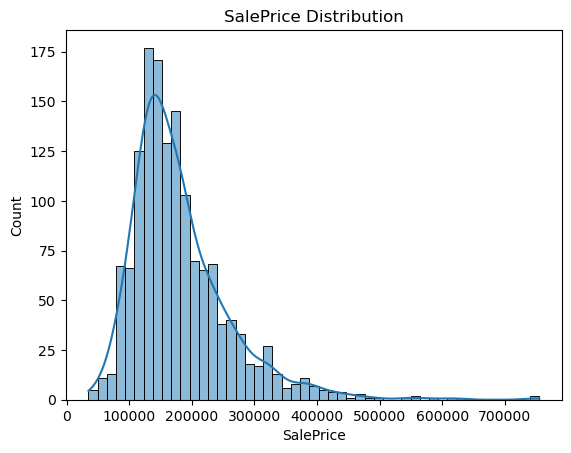

In [41]:
sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
print("SalePrice skew:", train['SalePrice'].skew())

Text(0.5, 1.0, 'Correlation Heatmap')

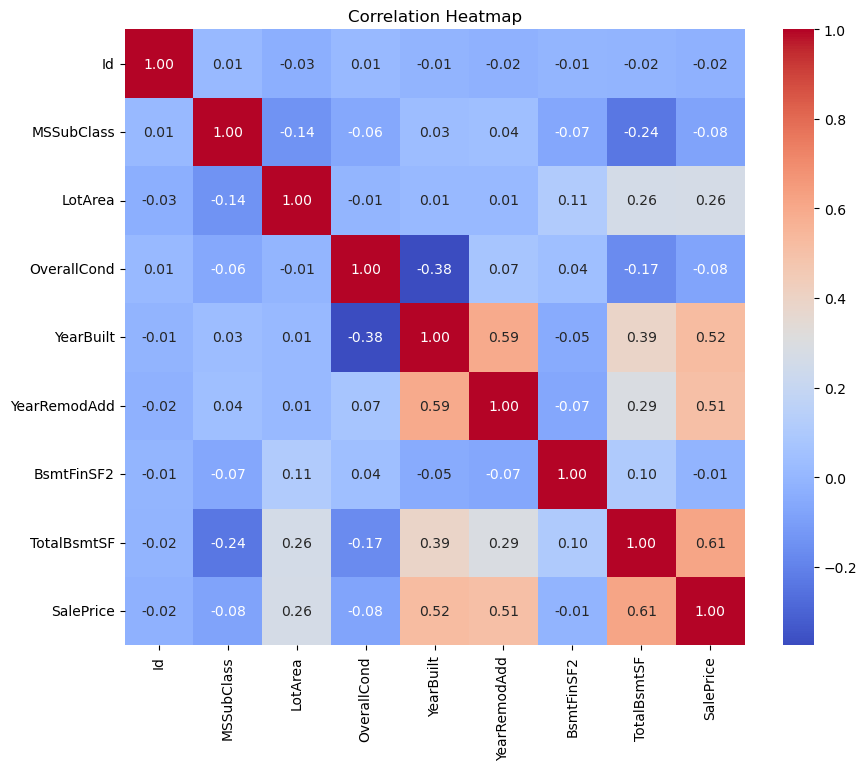

In [42]:
# Correlation heatmap (numeric features only)
numeric_cols = train.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

In [43]:
print(train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False))

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


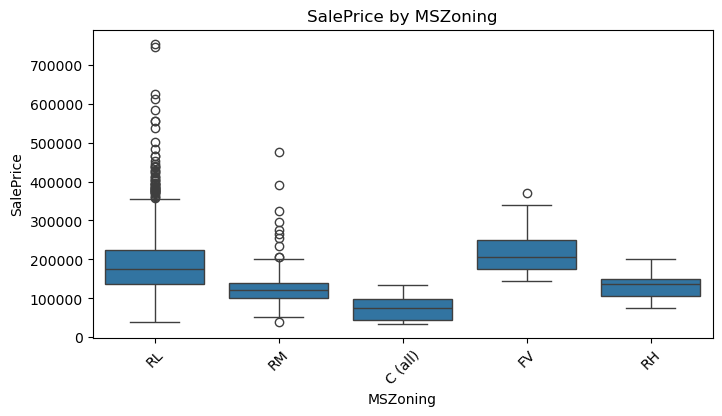

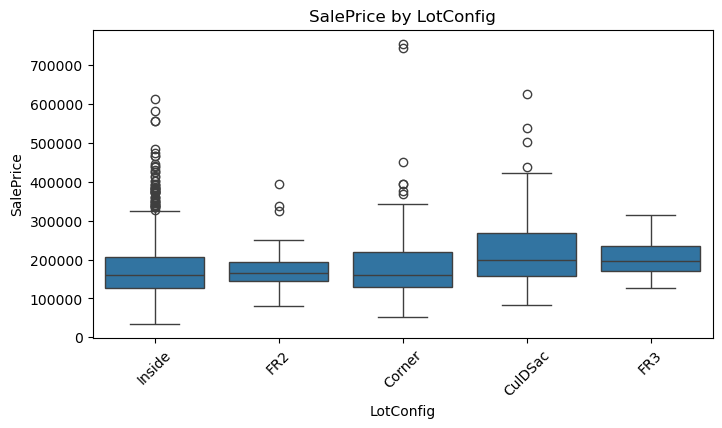

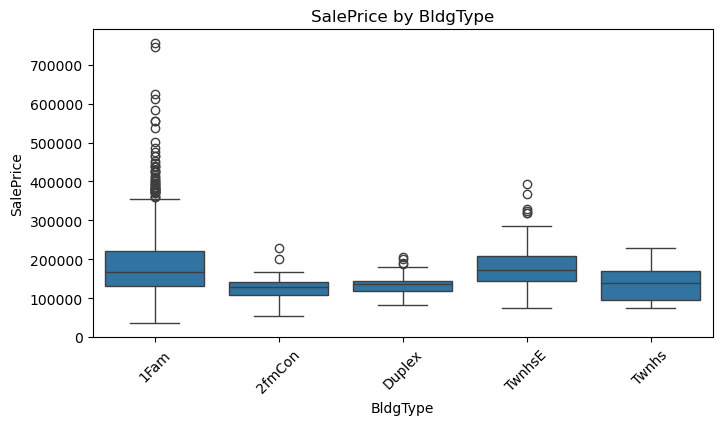

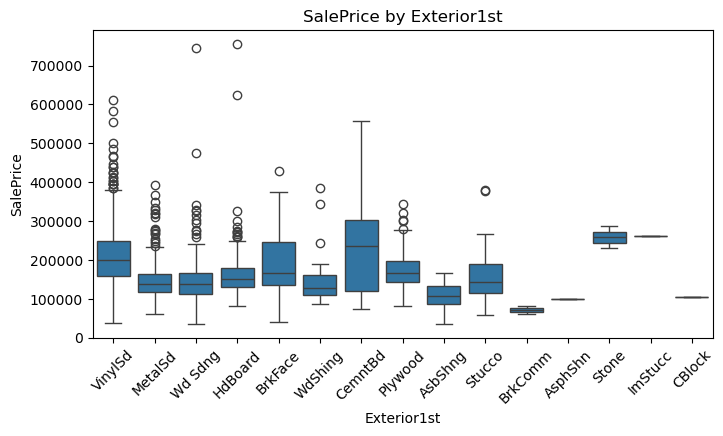

In [46]:
#Categorical features vs SalePrice
cat_cols = train.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y='SalePrice', data=train)
    plt.title(f'SalePrice by {col}')
    plt.xticks(rotation = 45)

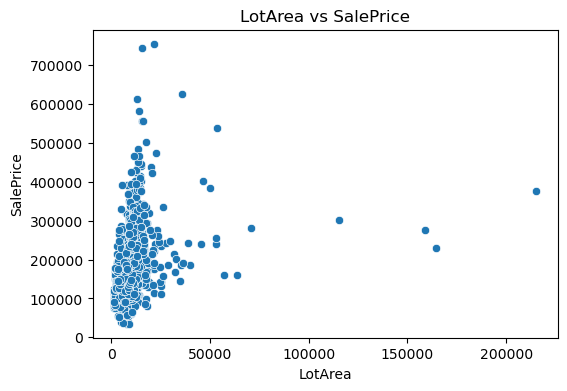

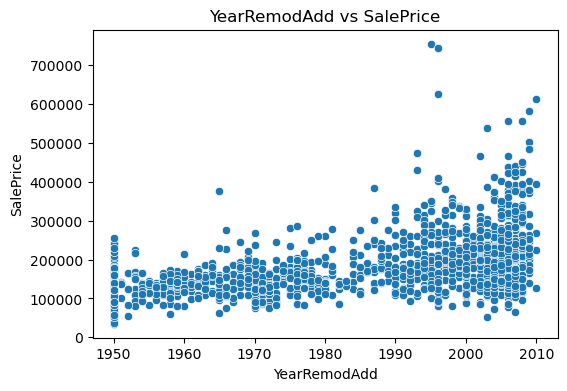

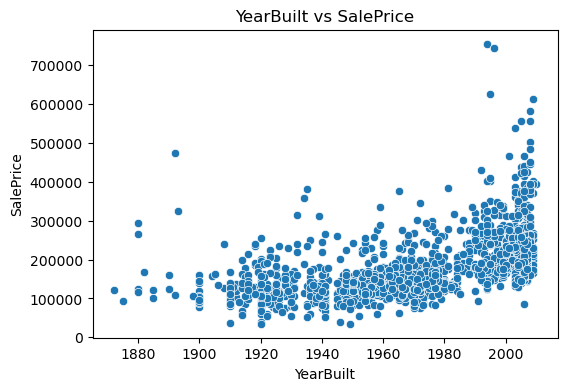

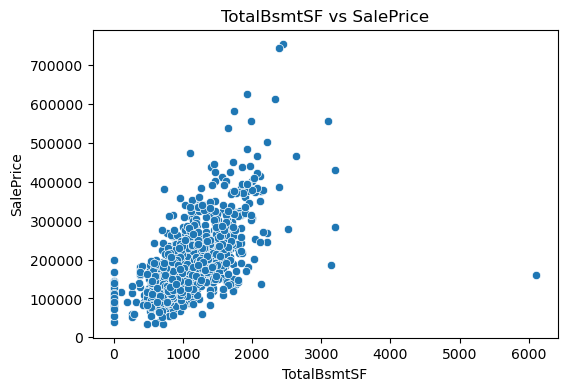

In [49]:
# outlier check
li = ["LotArea","YearRemodAdd","YearBuilt","TotalBsmtSF"]
for i in li:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x= i, y='SalePrice', data=train)
    plt.title(f'{i} vs SalePrice')